# 4. Mushroom foraging

The [mushroom dataset](https://www.kaggle.com/datasets/dhinaharp/mushroom-dataset) contains data about approximately 60000 mushrooms, and your task is to classify them as either edible or poisonous. You can read about the features [here](https://www.kaggle.com/datasets/uciml/mushroom-classification) and import the data using:

In [65]:
import pandas as pd
pd.set_option('display.max_columns', 1000)
df = pd.read_csv('secondary_data.csv', delimiter = ';')
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,17.09,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,18.19,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,17.74,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,15.98,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,17.20,s,y,w,u,w,t,p,NaN,d,w


It's up to you how you approach this data, but at a minimum, your analysis should include:

* Informed **data preparation**.
* 2 different classification models, one of which must be **logistic regression**.
* A discussion of which **performance metric** is most relevant for the evaluation of your models.
* 2 different **validation methodologies** used to tune hyperparameters.
* **Confusion matrices** for your models, and associated comments.

### Data analysis/cleansing

In [66]:
print(f"Nulls\n{df.isnull().sum()}")

data = df.drop(['stem-root', 'stem-surface', 'veil-type', 'veil-color', 'spore-print-color'], axis = 'columns')

data = data.drop_duplicates()

# these ones had an unknown = blank category in teh dataset
data['gill-attachment'] = data['gill-attachment'].fillna('unknown')
data['ring-type'] = data['ring-type'].fillna('unknown')

for column in ['cap-surface', 'gill-spacing']:
    data[column] = data[column].fillna(data[column].mode()[0])

print("\nNum poisonous/edible")
print(f"poisonous - {(data['class'] == 'p').sum()}")
print(f"edible - {(data['class'] == 'e').sum()}")


Nulls
class                       0
cap-diameter                0
cap-shape                   0
cap-surface             14120
cap-color                   0
does-bruise-or-bleed        0
gill-attachment          9884
gill-spacing            25063
gill-color                  0
stem-height                 0
stem-width                  0
stem-root               51538
stem-surface            38124
stem-color                  0
veil-type               57892
veil-color              53656
has-ring                    0
ring-type                2471
spore-print-color       54715
habitat                     0
season                      0
dtype: int64

Num poisonous/edible
poisonous - 33742
edible - 27181


### Encoding

In [67]:
data['class'] = data['class'].map({'e': False, 'p': True})
data['does-bruise-or-bleed'] = data['does-bruise-or-bleed'].map({'t': True, 'f' : False})
data['has-ring'] = data['has-ring'].map({'t': True, 'f' : False})

categories = [
    'cap-shape', 'cap-surface', 'cap-color', 'gill-attachment', 'gill-spacing', 'gill-color', 'stem-color', 'ring-type', 'habitat', 'season'
]

data = pd.get_dummies(data, columns = categories, drop_first = True)

### Scaling

In [68]:
from sklearn.preprocessing import StandardScaler

numericals = ['cap-diameter', 'stem-height', 'stem-width']
scaler = StandardScaler()
data[numericals] = scaler.fit_transform(data[numericals])

### Analyzing correlation

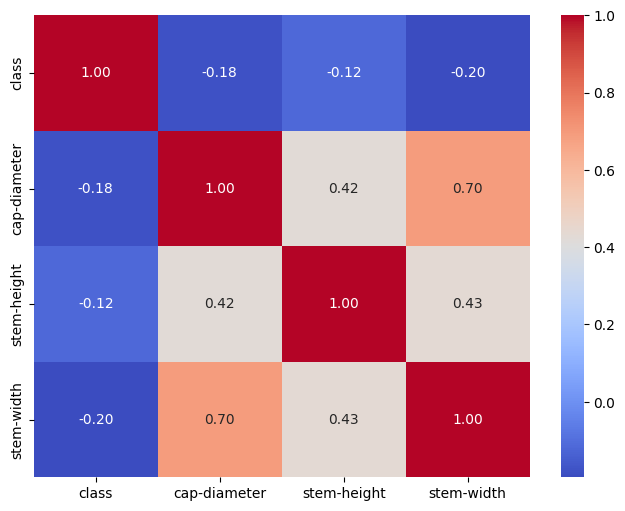

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_columns = ['class', 'cap-diameter', 'stem-height', 'stem-width']
corr_matrix = data[numerical_columns].corr()

plt.figure(figsize = (8, 6))
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm", fmt = '.2f')
plt.show()

In [70]:
# could potentially drop either cap-diameter or stem-width

### Splitting data

In [71]:
from sklearn.model_selection import train_test_split

features = data.drop('class', axis = 1)
label = data['class']

X_train, X_test, y_train, y_test = train_test_split(features, label, test_size = 0.2, random_state = 42)

X_train.head()

,cap-diameter,does-bruise-or-bleed,stem-height,stem-width,has-ring,cap-shape_c,cap-shape_f,cap-shape_o,cap-shape_p,cap-shape_s,cap-shape_x,cap-surface_e,cap-surface_g,cap-surface_h,cap-surface_i,cap-surface_k,cap-surface_l,cap-surface_s,cap-surface_t,cap-surface_w,cap-surface_y,cap-color_e,cap-color_g,cap-color_k,cap-color_l,cap-color_n,cap-color_o,cap-color_p,cap-color_r,cap-color_u,cap-color_w,cap-color_y,gill-attachment_d,gill-attachment_e,gill-attachment_f,gill-attachment_p,gill-attachment_s,gill-attachment_unknown,gill-attachment_x,gill-spacing_d,gill-spacing_f,gill-color_e,gill-color_f,gill-color_g,gill-color_k,gill-color_n,gill-color_o,gill-color_p,gill-color_r,gill-color_u,gill-color_w,gill-color_y,stem-color_e,stem-color_f,stem-color_g,stem-color_k,stem-color_l,stem-color_n,stem-color_o,stem-color_p,stem-color_r,stem-color_u,stem-color_w,stem-color_y,ring-type_f,ring-type_g,ring-type_l,ring-type_m,ring-type_p,ring-type_r,ring-type_unknown,ring-type_z,habitat_g,habitat_h,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,season_s,season_u,season_w
8113,-0.343930,False,-0.210556,-0.844292,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
4193,-0.533741,False,-0.234375,-0.861241,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False
53184,-0.028843,False,-0.165897,0.031058,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False
21430,-0.626749,False,-0.392173,-0.643899,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
43191,0.140089,True,0.563546,0.276315,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


### Performance metrics
These models are intended to predict whether or not the mushrooms in the dataset are edible. Considering the worst case scenario in which someone eats a mushroom that was incorrectly predicted to be edible (edible = negative, poisonous = positive), we want to focus on avoiding false negatives, which means focusing on recall.

### Hold out validation + logistic regressor

In [72]:
from sklearn.metrics import precision_score, recall_score, f1_score

def print_scores(type, predictions, actual):
    print(f"{type}")
    print(f"recall - {recall_score(actual, predictions):.2f}")
    print(f"precision - {precision_score(actual, predictions):.2f}")
    print(f"f1 - {f1_score(actual, predictions):.2f}\n")

def print_f1_graph(rec, prec, recall, precision):
    plt.figure(dpi = 800)
    plt.plot(rec, prec, 'b')
    plt.plot(recall, precision, 'bo')
    plt.xlabel('recall')
    plt.ylabel('precision')
    plt.title('recall vs precision')
    plt.show()

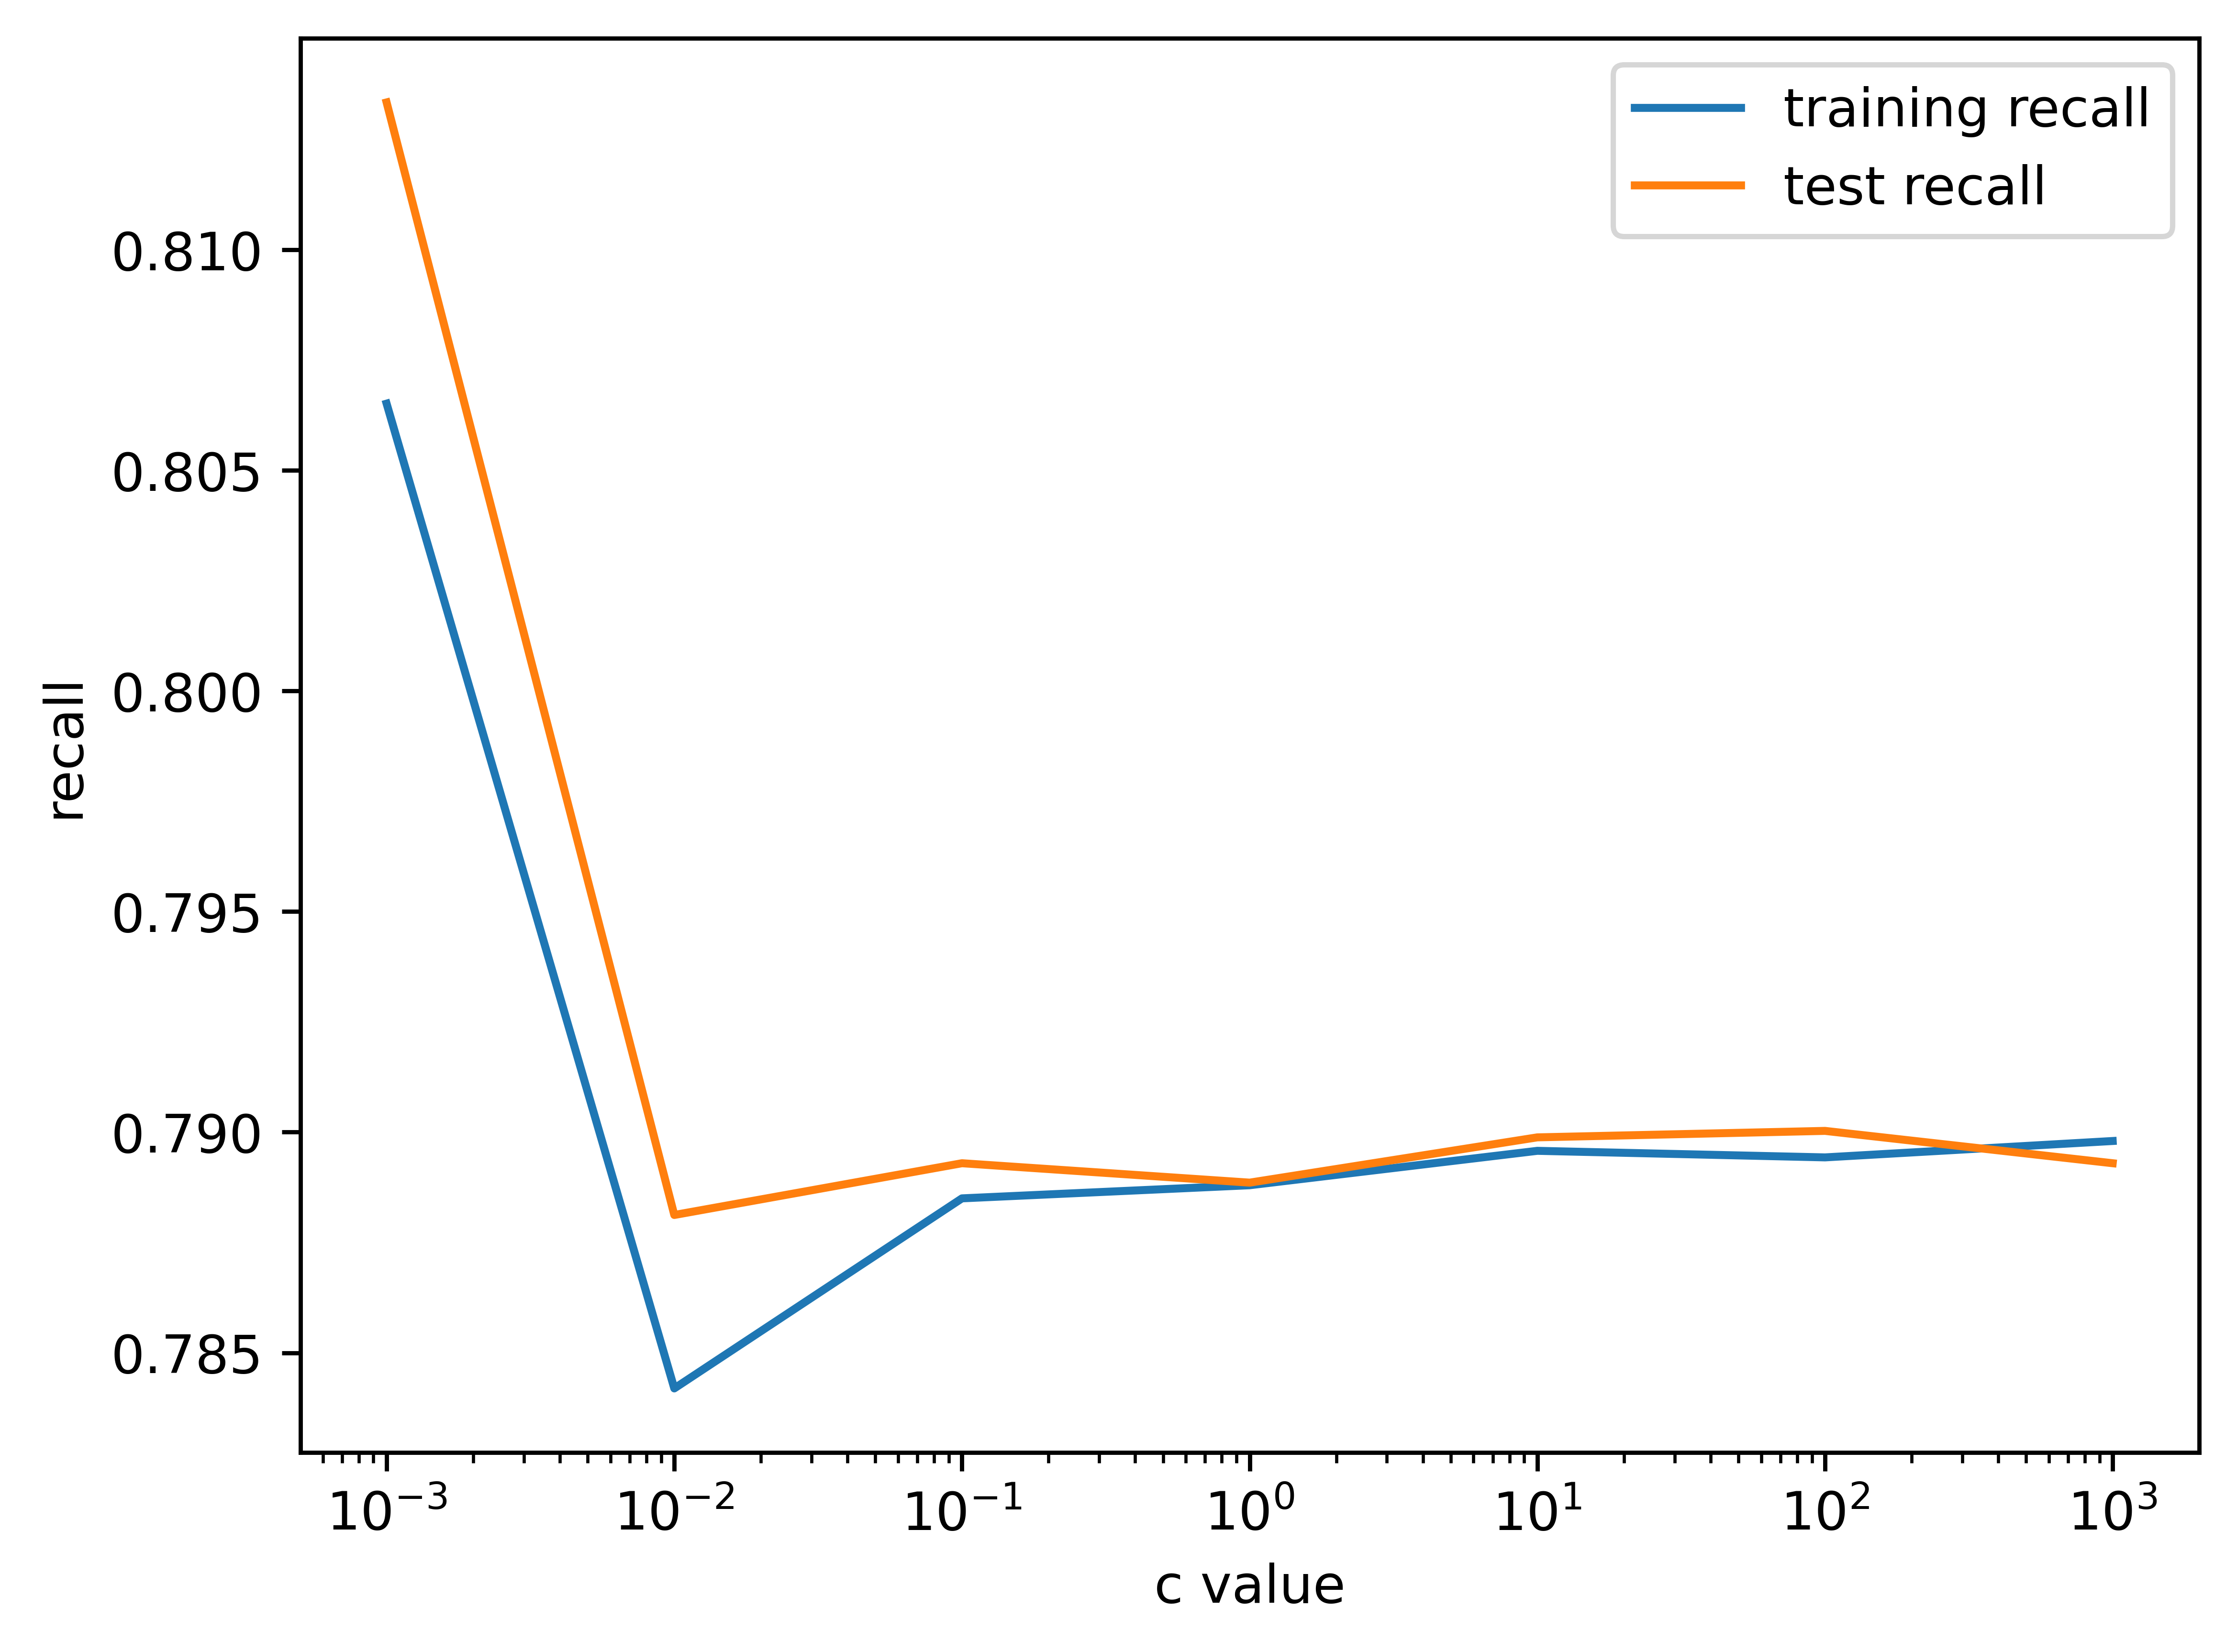

In [73]:
from sklearn.linear_model import LogisticRegression

c_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
training_recall = []
test_recall = []

for c in c_values:
    model = LogisticRegression(max_iter = 1000, random_state = 42, C = c)
    model.fit(X_train, y_train)
    train_results = model.predict(X_train)
    test_results = model.predict(X_test)

    train_recall = recall_score(y_train, train_results)
    testing_recall = recall_score(y_test, test_results)
    training_recall.append(train_recall)
    test_recall.append(testing_recall)


plt.figure(dpi = 800)
plt.plot(c_values, training_recall, label = "training recall")
plt.plot(c_values, test_recall, label = "test recall")
plt.ylabel("recall")
plt.xlabel("c value")
plt.xscale('log')
plt.legend()
plt.show()


testing adjusted for recall
recall - 0.99
precision - 0.59
f1 - 0.74

AUC - 0.89


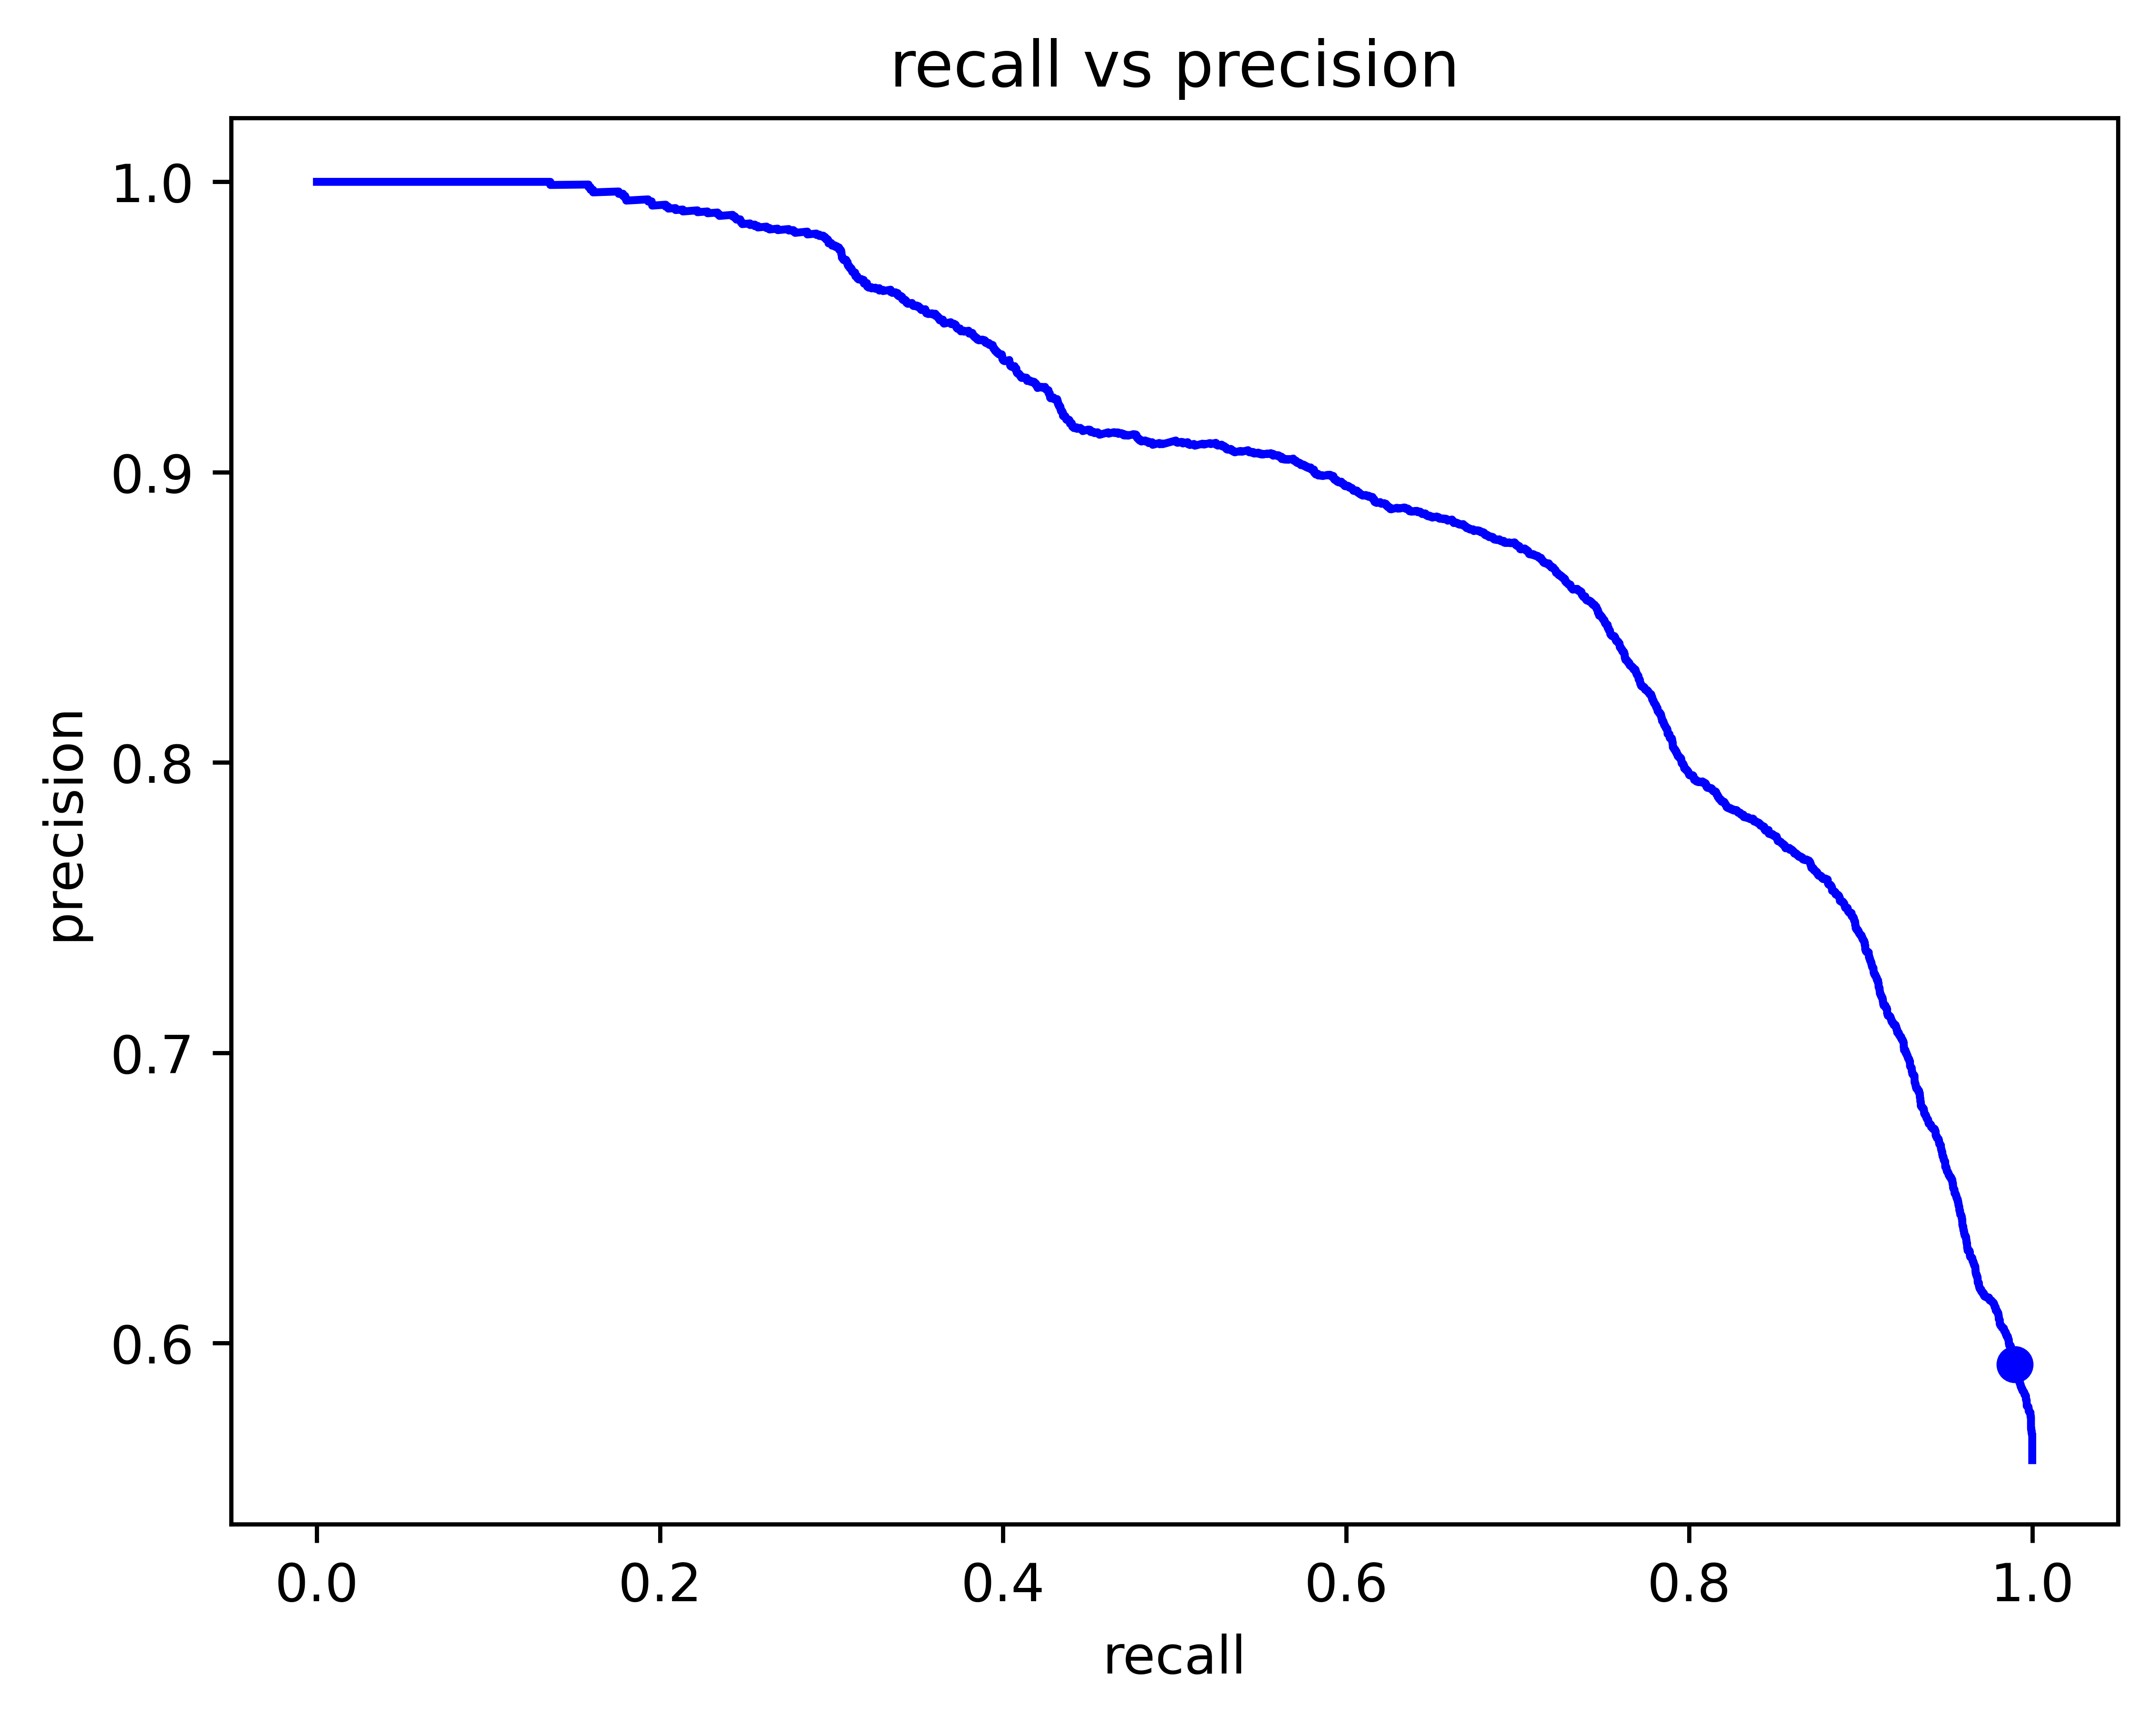

In [74]:
# seems like 10 or 100 is the best value for c..
from sklearn.metrics import precision_recall_curve, auc

model = LogisticRegression(max_iter = 1000, random_state = 42, C = 100)
model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:, 1]
predictions = model.predict(X_test)

prec, rec, thresholds = precision_recall_curve(y_test, probs)

idx_for_99_recall = (rec > 0.99).argmin()
threshold_for_99_recall = thresholds[idx_for_99_recall]
predictions_99_rec = (model.predict_proba(X_test)[:,1] >= threshold_for_99_recall)

print_scores("testing adjusted for recall", predictions_99_rec, y_test)
print(f"AUC - {auc(rec,prec):.2f}")
print_f1_graph(rec, prec, recall_score(y_test, predictions_99_rec), precision_score(y_test, predictions_99_rec))

In [75]:
from sklearn.metrics import confusion_matrix

matrix = confusion_matrix(y_test, predictions_99_rec)
print(matrix)

[[ 726 4639]
 [  69 6751]]


adjusting helped get rid of false negatives, but the tradeoff now is that there's a lot of false positives... so the model is pretty cautious

### KFold CV + random forest classifier

best parameters - {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 10}
testing
recall - 0.97
precision - 0.96
f1 - 0.96

AUC - 0.89


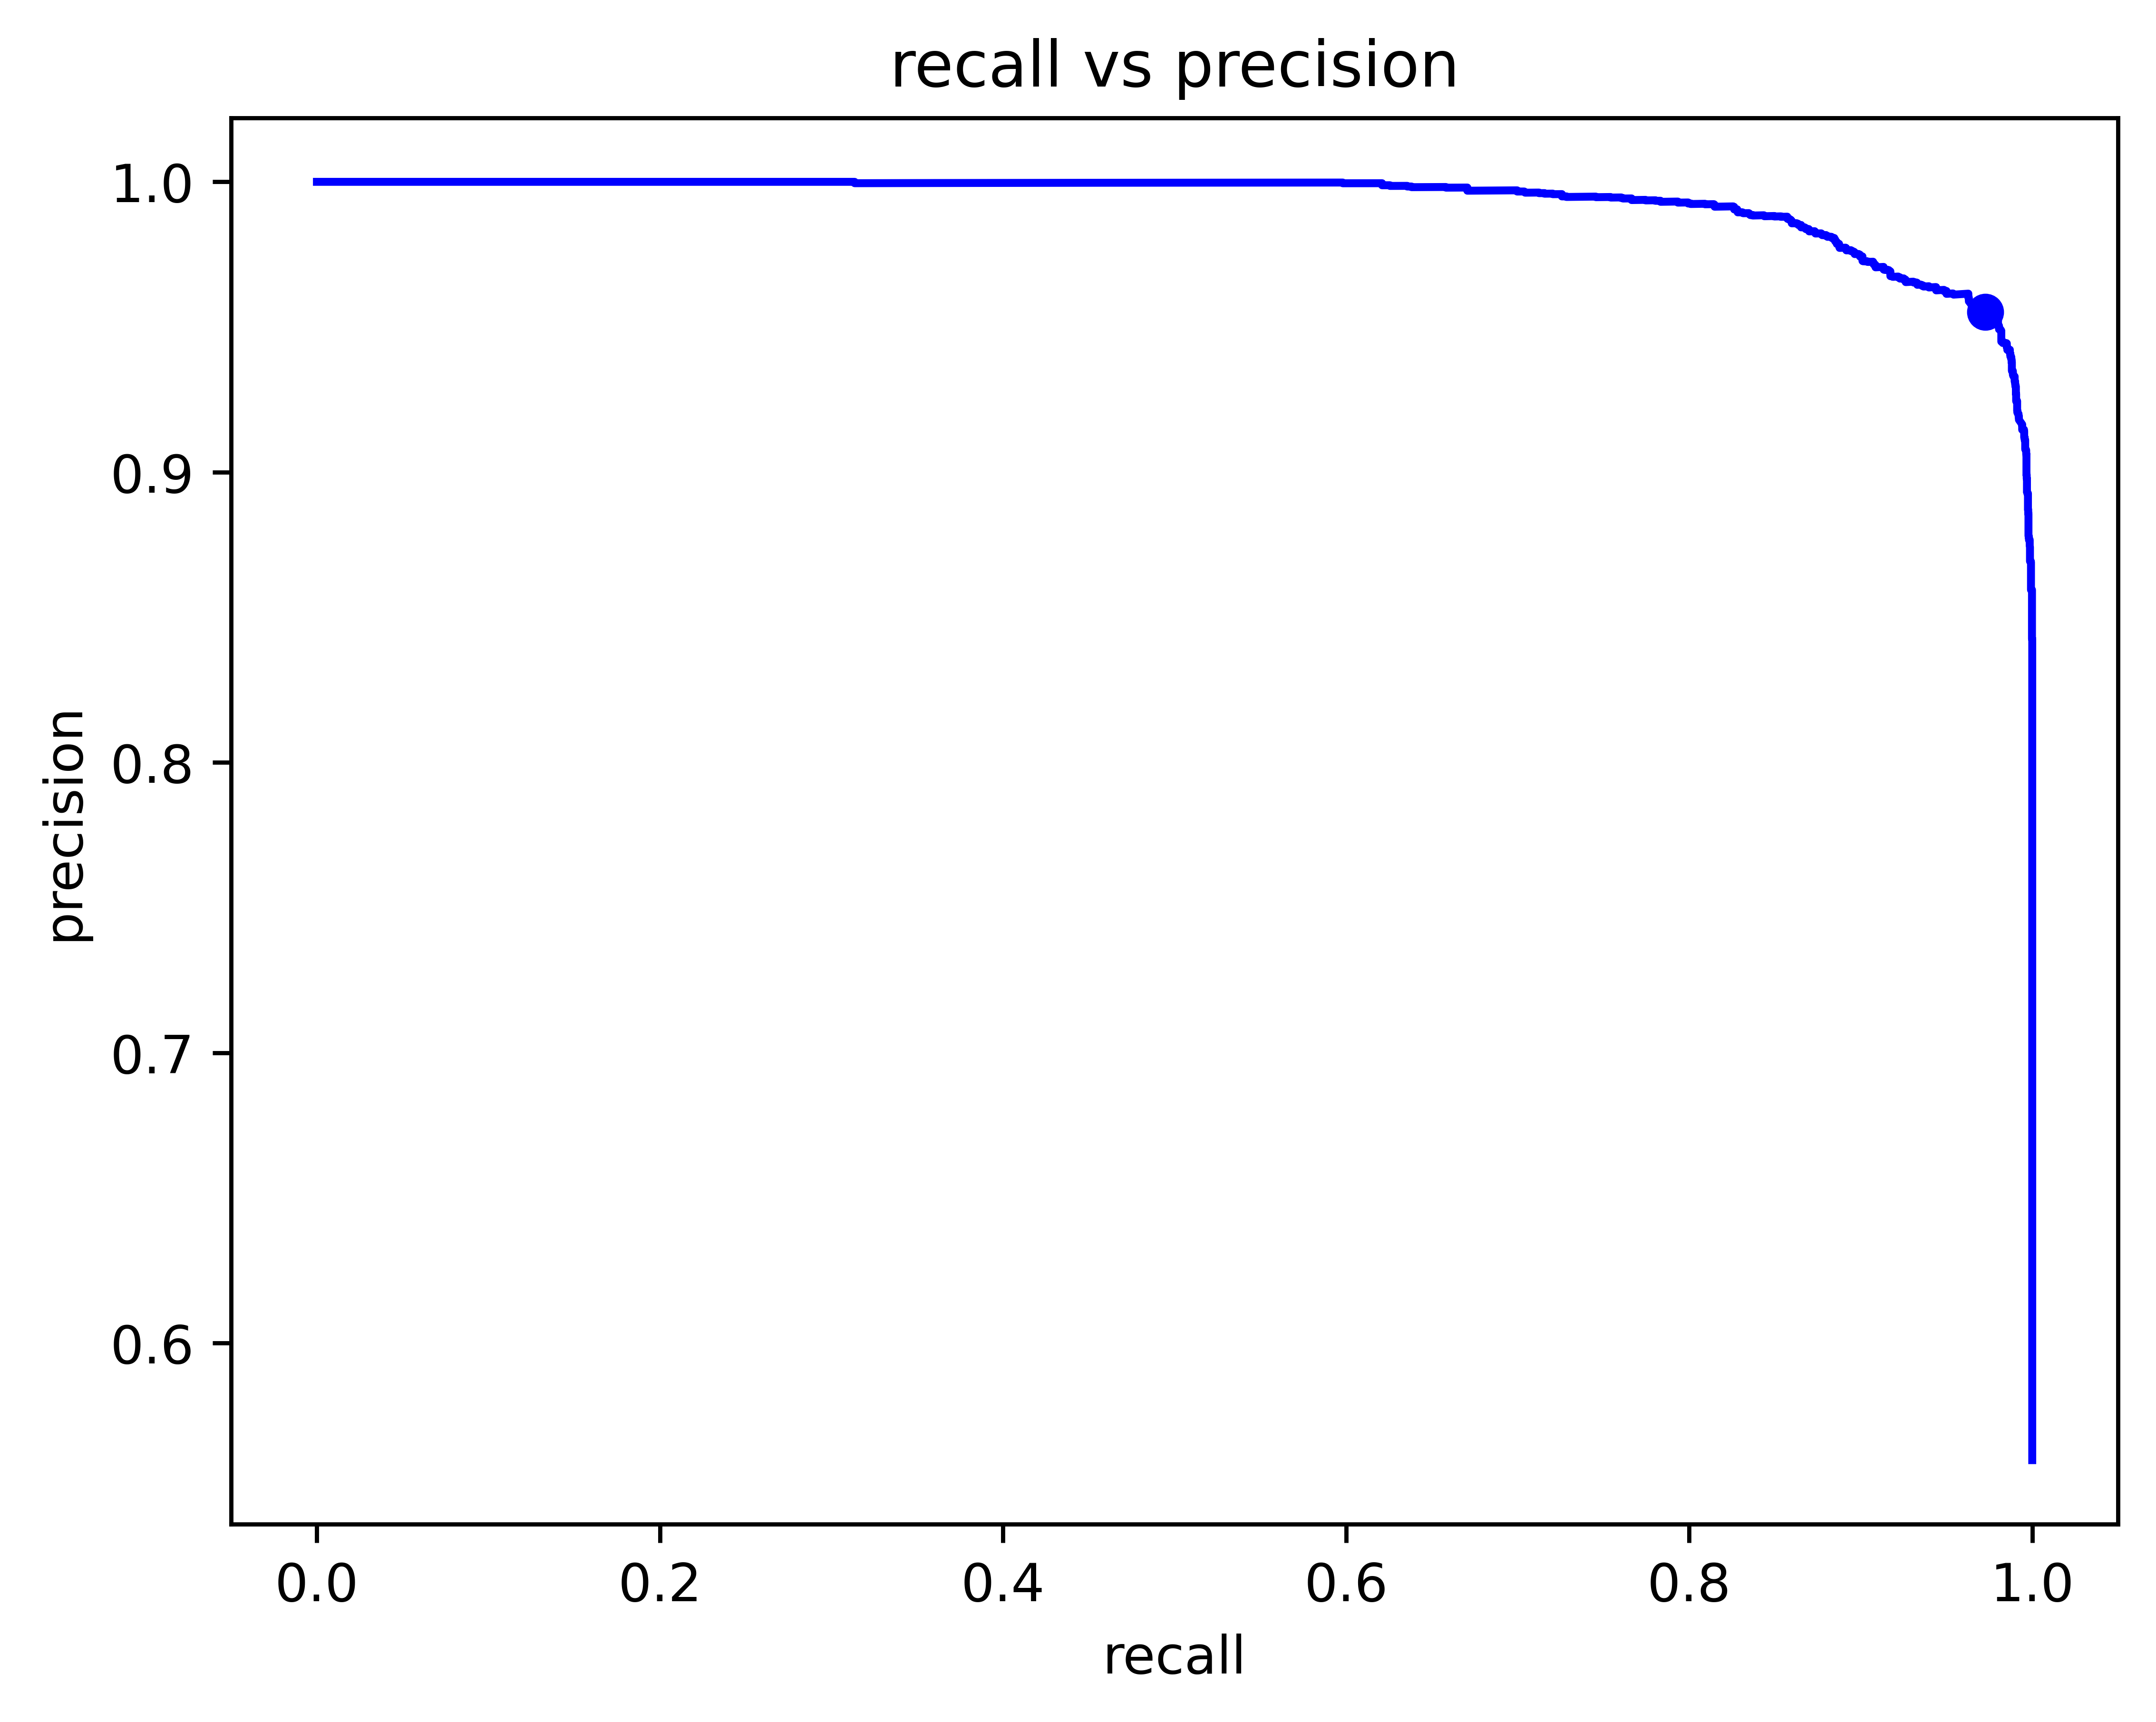

In [76]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state = 42)
grid_values = {
    'n_estimators': [5, 10],
    'max_depth': [1, 10],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 5]
}

skf = StratifiedKFold(n_splits = 4, shuffle = True, random_state = 42)
grid_search = GridSearchCV(estimator = model, param_grid = grid_values, cv = skf, n_jobs = -1, scoring = 'recall')

grid_search.fit(X_train, y_train)
print(f"best parameters - {grid_search.best_params_}")

test_probs = grid_search.predict_proba(X_test)[:, 1]
test_predictions = (test_probs >= 0.5)

print_scores("testing", test_predictions, y_test)
print(f"AUC - {auc(rec,prec):.2f}")
prec, rec, thresholds = precision_recall_curve(y_test, test_probs)
print_f1_graph(rec, prec, recall_score(y_test, test_predictions), precision_score(y_test, test_predictions))

In [77]:
matrix = confusion_matrix(y_test, test_predictions)
print(matrix)

[[5054  311]
 [ 186 6634]]


Adjusting for recall

testing adjusted for recall
recall - 0.99
precision - 0.93
f1 - 0.96

AUC - 0.99


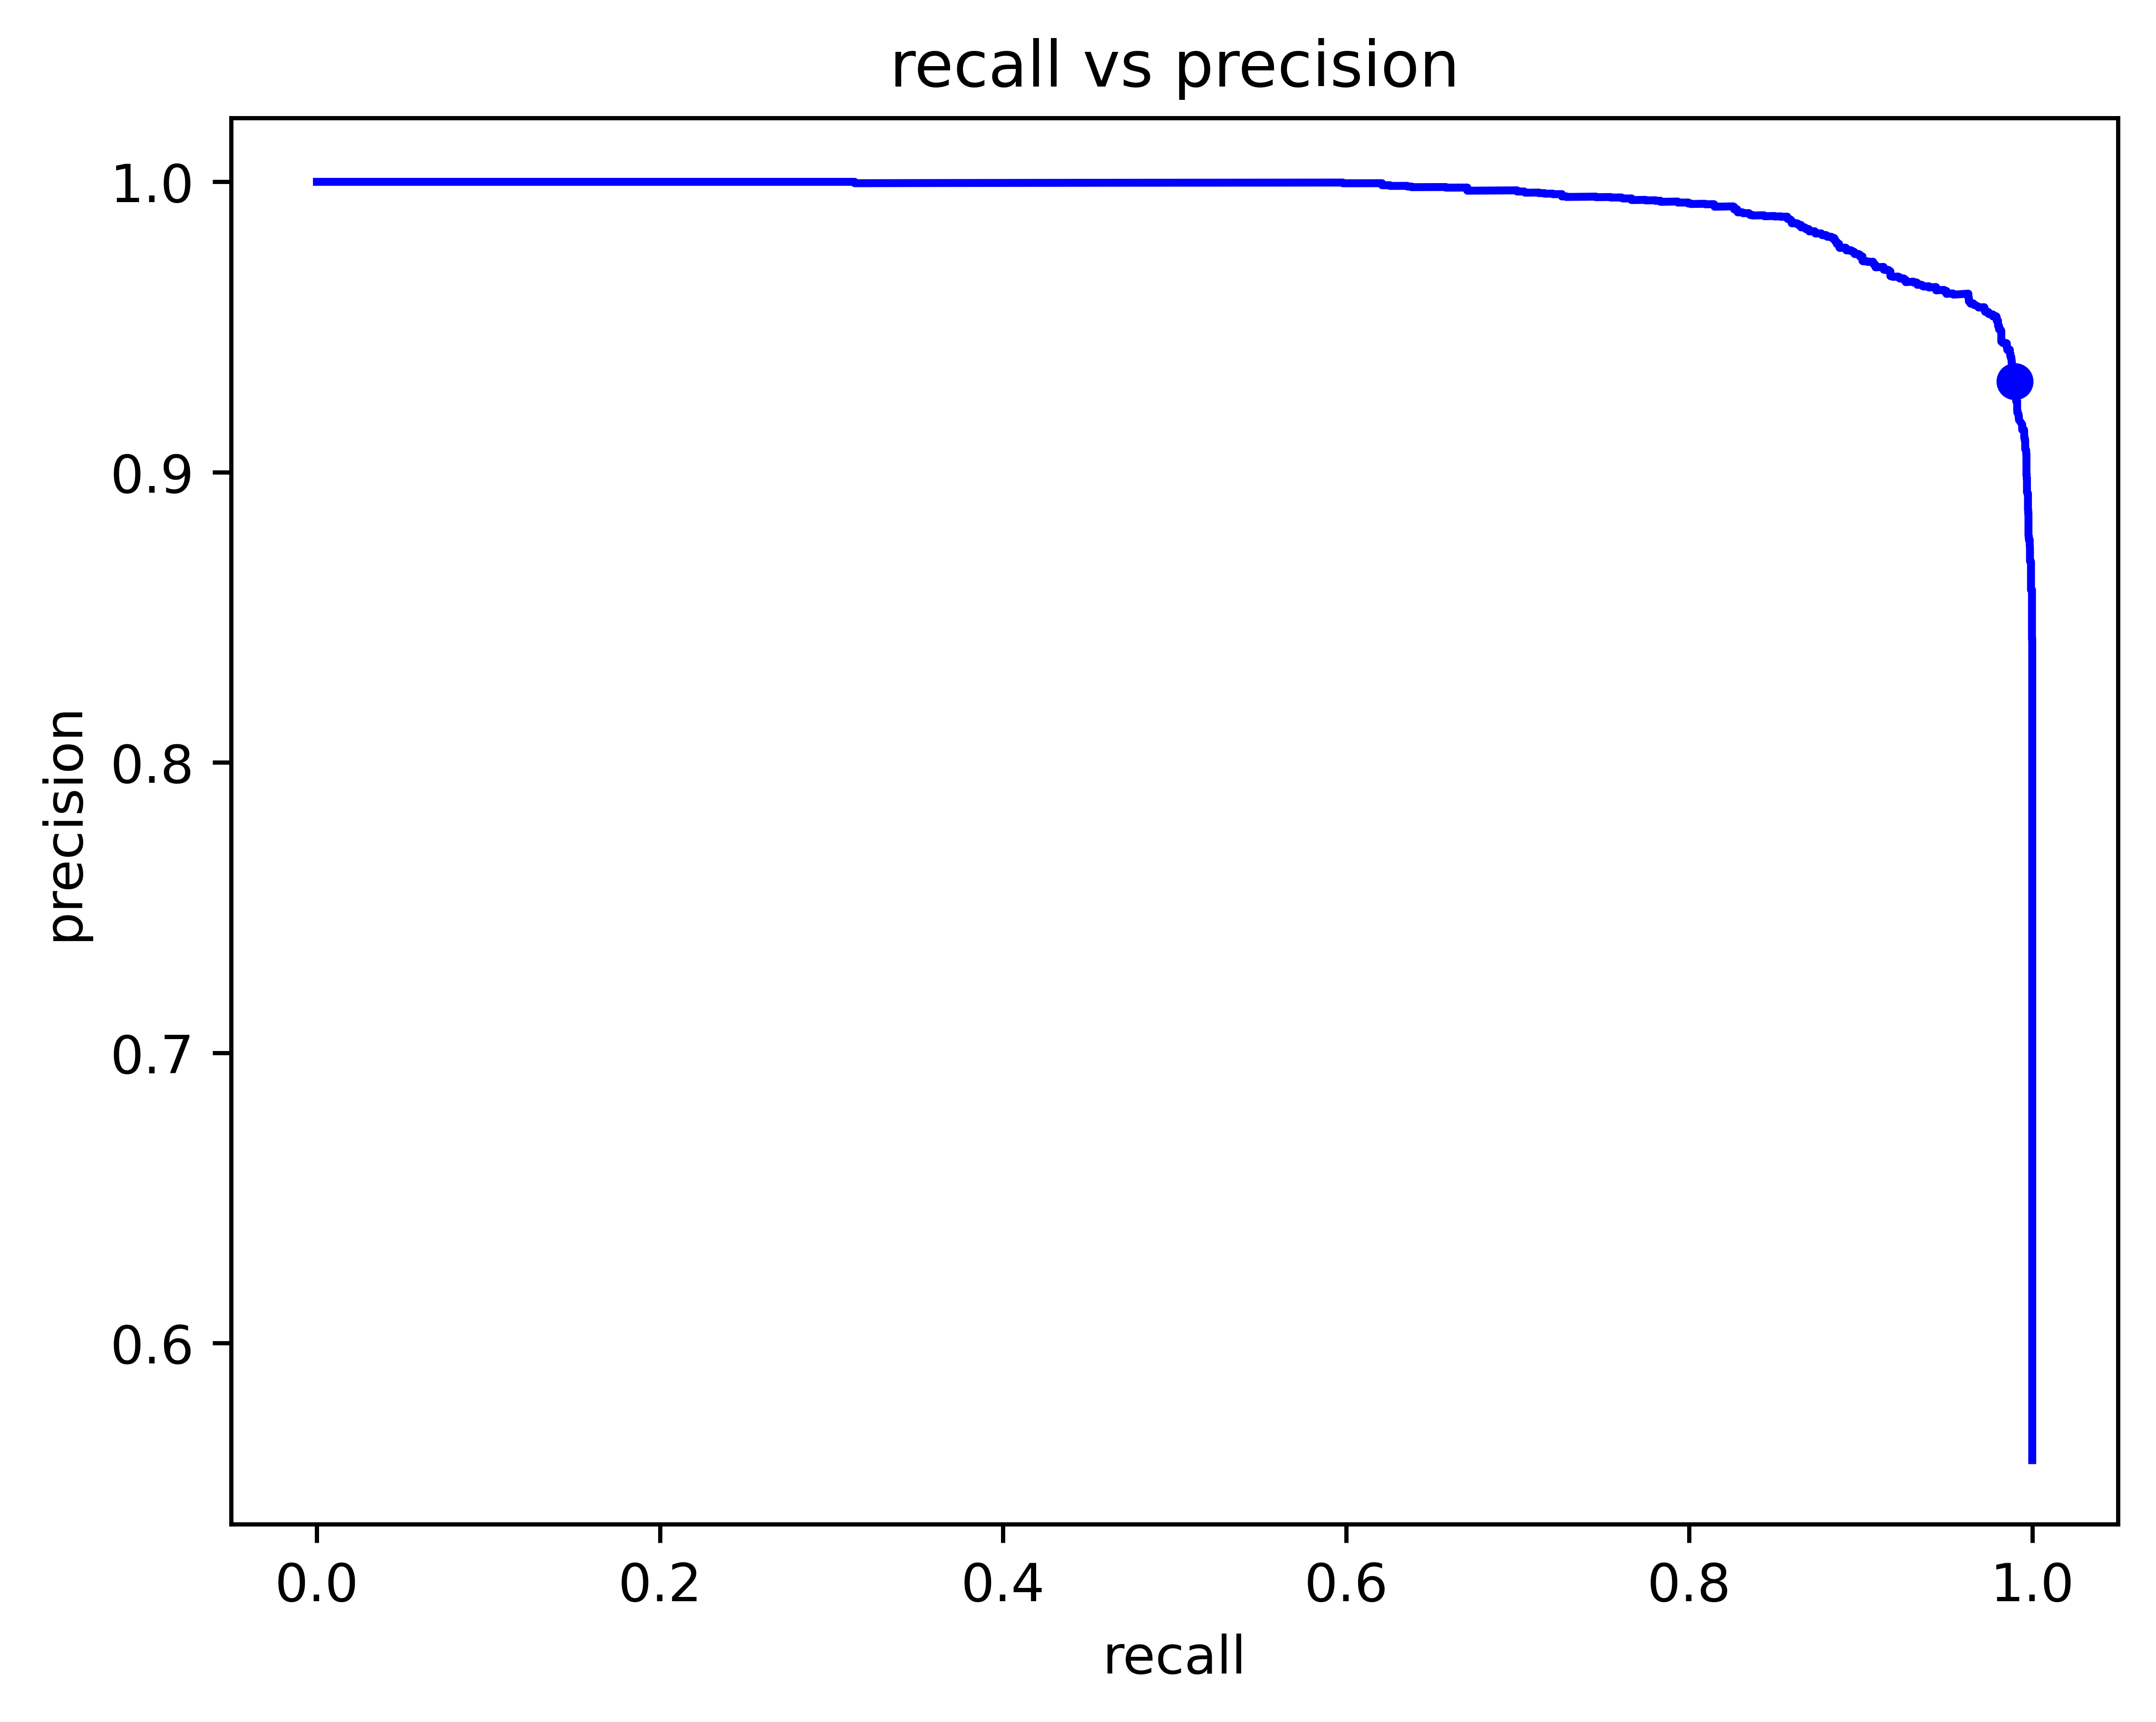

In [78]:
idx_for_99_recall = (rec > 0.99).argmin()
threshold_for_99_recall = thresholds[idx_for_99_recall]
predictions_99_rec = (grid_search.predict_proba(X_test)[:,1] >= threshold_for_99_recall)

print_scores("testing adjusted for recall", predictions_99_rec, y_test)
print(f"AUC - {auc(rec,prec):.2f}")
print_f1_graph(rec, prec, recall_score(y_test, predictions_99_rec), precision_score(y_test, predictions_99_rec))

In [79]:
matrix = confusion_matrix(y_test, predictions_99_rec)
print(matrix)

[[4867  498]
 [  70 6750]]


adjusting the threshold seems to have helped eliminate almost all false negatives

In [80]:
feature_importances = pd.Series(grid_search.best_estimator_.feature_importances_, index = X_train.columns)
feature_importances.sort_values(ascending = False).head()

stem-width        0.110492
stem-height       0.068547
cap-diameter      0.065396
stem-color_w      0.057851
gill-spacing_d    0.054304
dtype: float64